In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
%matplotlib inline

In [5]:
df= pd.read_csv('weight.csv')

In [6]:
df.head()
# df.info()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

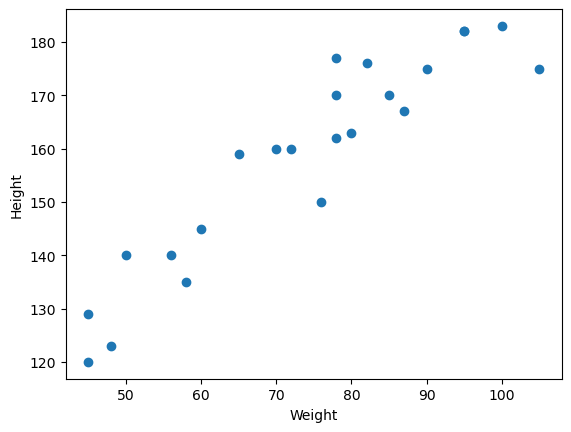

In [7]:
## scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [8]:
# Finding correletion
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


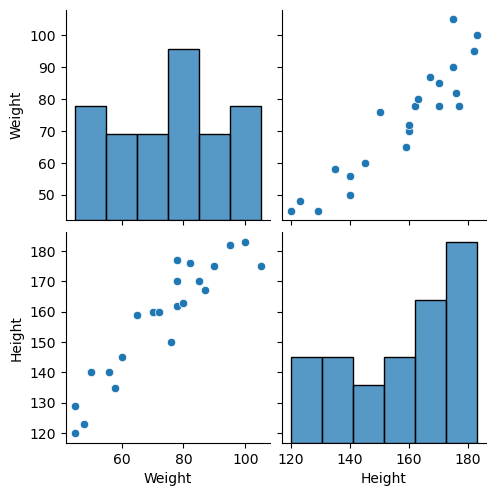

In [9]:
# Seaborn visuluaization
import seaborn as sns
sns.pairplot(df)

In [10]:
# independed and depended feature
# X=df[['Weight']] #independent Feature should be data frame or 2 dimensional
X=df['Weight']
# np.array(X).shape
X.head()

0    45
1    58
2    48
3    60
4    70
Name: Weight, dtype: int64

In [11]:
X=df[['Weight'] ]# its independed feature
y=df['Height']


In [12]:
X_seris=df['Weight']
np.array(X_seris).shape

(23,)

In [13]:
np.array(y).shape

(23,)

In [14]:
## Train Test Spliting
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=42)

In [15]:
# Standard dization
from sklearn.preprocessing import StandardScaler
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [16]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [17]:
X_test=scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [18]:
# Apply Simple linner rigresion
from sklearn.linear_model import LinearRegression
regression=LinearRegression()


In [19]:
regression.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
regression.coef_

array([17.2982057])

In [21]:
print("Cofficent or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Cofficent or slope: [17.2982057]
Intercept: 156.47058823529412


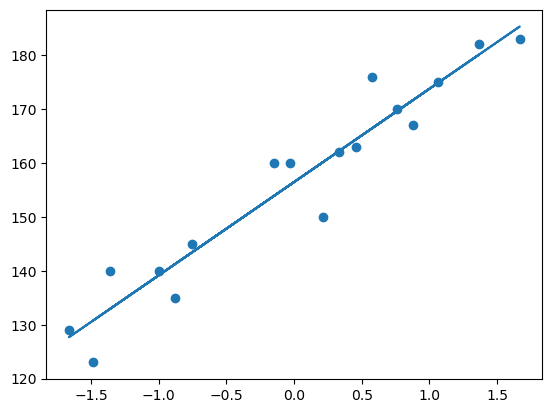

In [22]:
## Plot training data for best fit
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [23]:
# pridiction For test data
y_pred=regression.predict(X_test)

In [24]:
# perfomace matrix  
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [25]:
mse=mean_squared_error(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [26]:
from sklearn.metrics import r2_score

In [27]:
score=r2_score(y_test,y_pred)
score

0.7360826717981276

### Adjusted R^2 = 1-[(1-R2)*(n-1)/(n-k-1)]

In [28]:
# disply adjuste R- Square
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[-1]-1)

0.6701033397476595

In [29]:
## OLs Regression
import statsmodels.api as sm

In [31]:
model= sm.OLS(y_train,X_train).fit()

In [33]:
prediction= model.predict(X_test)
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Mon, 18 May 2026   Prob (F-statistic):                       0.664
Time:                        12:08:36   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [37]:
# pridiction new data
regression.predict(scaler.transform([[72]]))

/home/ashish/miniforge3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])